# Configuracion Inicial

In [1]:
import sys
import os

# Obtener la ruta absoluta de la carpeta 'notebooks'
notebook_dir = os.getcwd()

# Subir un nivel para llegar a la raíz del proyecto ('cuentas')
project_root = os.path.dirname(notebook_dir)

# Añadir la raíz del proyecto a la ruta de búsqueda de Python
if project_root not in sys.path:
    sys.path.insert(0, project_root)


In [2]:
import pandas as pd
# from contabilidad.analisis.datosCrudos import ver_fecha_dudosa
from contabilidad.analisis.datosCrudos import VisualizadorFinanciero,visualizar_cuenta

In [3]:
from contabilidad.config import PATH_ACTUAL
PATH_ACTUAL

'validacion/2026-01-08'

# Cuenta

In [4]:
%load_ext autoreload
%autoreload 2

import contabilidad.modulos.cuenta.lectura.cuenta as LecturaCuenta
import contabilidad.modulos.cuenta.validacion as ValidacionCuenta
from contabilidad.modulos.cuenta.lectura.FileProcessingConfig import FileProcessingConfig

PATH ACTUAL: c:\Users\andre\Programacion\Cuentas\notebooks


In [5]:
config_new_file = None

## Lectura

### Ingresar Nueva Cuentas

In [34]:
%load_ext autoreload
%autoreload 2
from contabilidad.config import PATH_BANCA_NUEVOS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from ipyfilechooser import FileChooser
from IPython.display import display
fc = FileChooser(PATH_BANCA_NUEVOS) 
display(fc)

FileChooser(path='C:\Users\andre\Programacion\Cuentas\data\nuevos\banca', filename='', title='', show_hidden=F…

Encabezados encontrados en la fila 5 (Excel)


<Axes: title={'center': 'Saldo Cuenta Nuevo Formato'}, xlabel='FECHA'>

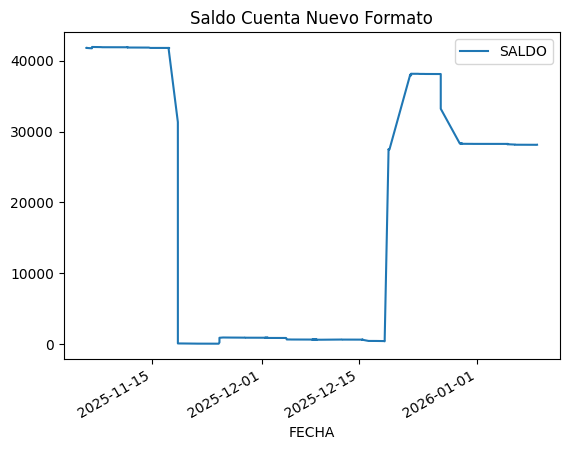

In [36]:
config_new_file =FileProcessingConfig(
    path=PATH_BANCA_NUEVOS +"/" + fc.selected_filename, 
)
df_nueva_cuenta=LecturaCuenta.leer_cuenta_nuevo(config_new_file)
df_nueva_cuenta.plot(x='FECHA', y='SALDO', title='Saldo Cuenta Nuevo Formato')

In [53]:
df_nueva_cuenta.query("FECHA >= '2025-10-30'").head(20)

,FECHA,SALDO,DESCRIPCION,DEBITO,CREDITO,MONTO
0,2025-11-05 13:34:00,41799.55,2511051XGVNA-MASTE BP-REC-22306700007562,141.95,0.0,-141.95
1,2025-11-05 12:46:00,41795.55,TRANSF. DEUNA A ERICK EDUARDO MOSQUERA HERRERA,4.00,0.0,-4.00
2,2025-11-06 07:21:00,41745.55,TRANSF. DIRECTA A PAZMIÑO VALLEJO NORMA ISABEL,50.00,0.0,-50.00
3,2025-11-06 09:00:00,41744.80,TRANSF. DIRECTA A ANDRADE PALADINES DANAHE,0.75,0.0,-0.75
4,2025-11-06 09:07:00,41854.80,TRANSF. DIRECTA DE ARCINIEGA BASANTES PAULINA ...,0.00,110.0,110.00
5,2025-11-06 09:08:00,41929.80,TRANSF. DIRECTA DE ARCINIEGA BASANTES PAULINA ...,0.00,75.0,75.00
6,2025-11-06 12:54:00,41925.80,TRANSF. DEUNA A ERICK EDUARDO MOSQUERA HERRERA,4.00,0.0,-4.00
7,2025-11-06 18:22:00,41925.41,COBRO DE IVA POR PAGO DE SERVICIOS BANCARIOS,0.05,0.0,-0.05
8,2025-11-06 18:22:00,41922.90,PAGO TARJETA INTERBANCARIA ENVIADA,2.51,0.0,-2.51
9,2025-11-07 13:29:00,41912.90,TRANSF. DIRECTA A ENCALADA ENCALADA OSMAN FREDDY,10.00,0.0,-10.00


In [37]:
ValidacionCuenta.probar_validez_saldo(df_nueva_cuenta)

Probando validez de saldos... con diferencia permitida de  1


In [ ]:
# visualizar_cuenta(df_nueva_cuenta)

### Lectura Cuenta

In [38]:
df_cuenta= LecturaCuenta.obtener_todas_cuentas(config_new_file)

Leyendo archivo nuevo: ../data/nuevos/banca/Movimientos_cuenta_20251101_20260111.xlsx
Encabezados encontrados en la fila 5 (Excel)
-----------COMPARANDO DATOS NUEVOS CON ANTERIORES
Cargando datos anteriores de: ../data/completos/validacion/2026-01-08/banca.xlsx
Rango común de fechas: 2025-11-05 → 2025-12-09
SALDO INICIAL: Nuevo [41799.55 41795.55] Anterior [41799.55 41795.55]
SALDO FINAL: Nuevo [646.86] Anterior [646.86]

No hay fechas nuevas.

No hay fechas eliminadas.

=== Cambios en fechas comunes (2025-11-05 → 2025-12-09) ===
Fecha inicio nuevo archivo: 2025-11-05 00:00:00
                FECHA     SALDO  \
0 2025-11-05 13:34:00  41799.55   
1 2025-11-05 12:46:00  41795.55   
2 2025-11-06 07:21:00  41745.55   
3 2025-11-06 09:00:00  41744.80   
4 2025-11-06 09:07:00  41854.80   
5 2025-11-06 09:08:00  41929.80   
6 2025-11-06 12:54:00  41925.80   
7 2025-11-06 18:22:00  41925.41   
8 2025-11-06 18:22:00  41922.90   
9 2025-11-07 13:29:00  41912.90   

                              

2024-03-11 - 2026-01-09


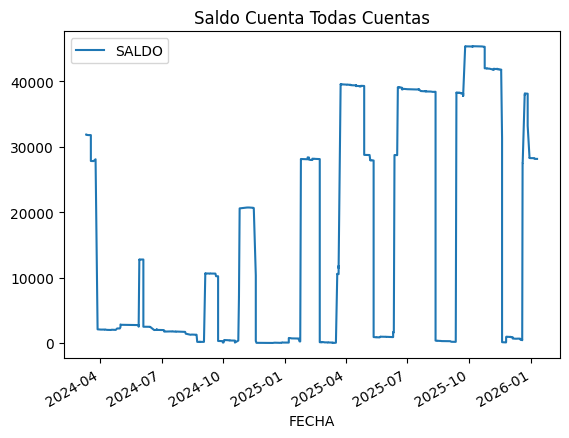

In [42]:
df_cuenta.plot(x='FECHA', y='SALDO', title='Saldo Cuenta Todas Cuentas')
print(df_cuenta["FECHA"].min().date(),"-", df_cuenta["FECHA"].max().date())

In [43]:
ValidacionCuenta.probar_validez_saldo(df_cuenta)

Probando validez de saldos... con diferencia permitida de  1
Saldo incorrecto en 2024-04-01 00:00:00: esperado 2046.1, encontrado 2058.79
Saldo Ant 2086.1, Saldo Act 2058.79, MONTO -40.0
DIFERENCIA 12.690000000000055


Saldo incorrecto en 2024-06-11 00:00:00: esperado 2479.86, encontrado 2483.41
Saldo Ant 2482.86, Saldo Act 2483.41, MONTO -3.0
DIFERENCIA 3.549999999999727


Saldo incorrecto en 2024-06-12 00:00:00: esperado 2479.41, encontrado 2476.41
Saldo Ant 2486.41, Saldo Act 2476.41, MONTO -7.0
DIFERENCIA -3.0


Saldo incorrecto en 2024-09-09 00:00:00: esperado 10625.65, encontrado 10627.25
Saldo Ant 10625.88, Saldo Act 10627.25, MONTO -0.23
DIFERENCIA 1.6000000000003638


Saldo incorrecto en 2024-09-11 00:00:00: esperado 10614.88, encontrado 10616.64
Saldo Ant 10618.63, Saldo Act 10616.64, MONTO -3.75
DIFERENCIA 1.7600000000002183


Saldo incorrecto en 2024-10-01 00:00:00: esperado 65.82, encontrado 67.81
Saldo Ant 69.32, Saldo Act 67.81, MONTO -3.5
DIFERENCIA 1.990000000000009




## Agrupar por Dia

In [44]:
df_cuenta_dias_unicos = df_cuenta.copy()
df_cuenta_dias_unicos["FECHA"] = df_cuenta_dias_unicos["FECHA"].dt.normalize()
df_cuenta_dias_unicos = df_cuenta_dias_unicos.groupby("FECHA").agg({
    "DEBITO": "sum",
    "CREDITO": "sum",
    "SALDO": "last",
    "MONTO": "sum",
}).reset_index()

In [45]:
ValidacionCuenta.probar_validez_saldo(df_cuenta_dias_unicos)

Probando validez de saldos... con diferencia permitida de  1
Saldo incorrecto en 2024-04-01 00:00:00: esperado 2034.1, encontrado 2046.79
Saldo Ant 2086.1, Saldo Act 2046.79, MONTO -52.0
DIFERENCIA 12.690000000000055


Saldo incorrecto en 2024-06-11 00:00:00: esperado 2482.86, encontrado 2486.41
Saldo Ant 2482.86, Saldo Act 2486.41, MONTO 0.0
DIFERENCIA 3.549999999999727


Saldo incorrecto en 2024-06-12 00:00:00: esperado 2479.41, encontrado 2476.41
Saldo Ant 2486.41, Saldo Act 2476.41, MONTO -7.0
DIFERENCIA -3.0


Saldo incorrecto en 2024-09-09 00:00:00: esperado 10620.779999999999, encontrado 10622.38
Saldo Ant 10625.88, Saldo Act 10622.38, MONTO -5.1
DIFERENCIA 1.6000000000003638


Saldo incorrecto en 2024-09-11 00:00:00: esperado 10614.88, encontrado 10616.64
Saldo Ant 10622.38, Saldo Act 10616.64, MONTO -7.5
DIFERENCIA 1.7600000000002183


Saldo incorrecto en 2024-10-01 00:00:00: esperado 65.82, encontrado 67.81
Saldo Ant 69.32, Saldo Act 67.81, MONTO -3.5
DIFERENCIA 1.99000000000

<Axes: title={'center': 'Saldo Cuenta Todas Cuentas'}, xlabel='FECHA'>

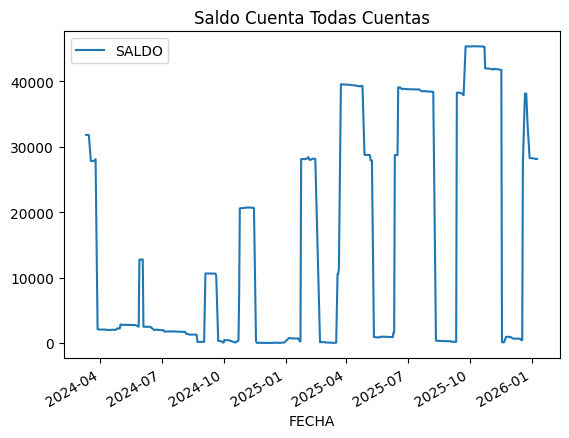

In [46]:
df_cuenta_dias_unicos.plot(x='FECHA', y='SALDO', title='Saldo Cuenta Todas Cuentas')

# Tarjeta

## Nueva

In [47]:
%load_ext autoreload
%autoreload 2
from contabilidad.tarjeta import generar_data_limpia as GenerarDataTarjeta
import contabilidad.config as Config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from ipyfilechooser import FileChooser
from IPython.display import display
fc = FileChooser(Config.PATH_TARJETA_NUEVOS) 
display(fc)

FileChooser(path='C:\Users\andre\Programacion\Cuentas\data\nuevos\tarjeta', filename='', title='', show_hidden…

In [146]:
path_tarjeta = Config.PATH_TARJETA_NUEVOS + "/" + fc.selected_filename
GenerarDataTarjeta.extraer_data_tarjeta(path_tarjeta)

Procesando archivo: ..\data\nuevos\tarjeta\Enero26.xls
________--------------REVISAR SUBTOTAL PAGOS NAN-----------------__________
Archivo guardado en: ..\data\procesada\tarjeta\2026-01.xlsx


DATOS_TARJETA_COMPLETA(MIN_FECHA_MOVIMIENTO=Timestamp('2025-12-05 00:00:00'), MAX_FECHA_MOVIMIENTO=Timestamp('2026-01-04 00:00:00'), TOTAL_A_PAGAR=np.float64(439.79), TOTAL_CONSUMO=np.float64(433.89), MINIMO_A_PAGAR=np.float64(21.39), DEUDAS_MES_ANTERIOR=np.float64(0.0), SUBTOTAL_PAGADO=np.float64(163.72), SALDO_ANTERIOR=np.float64(163.72), EMPRESA='ARCENTALES ARCINIEGA ANDRE SEB', NUM_TARJETA='2230XXXXXXXX5647', FECHA_MAX_PAGO=datetime.datetime(2026, 1, 21, 0, 0), FECHA_EMISION=datetime.datetime(2026, 1, 6, 0, 0))

In [ ]:
# GenerarDataTarjeta.extraer_data_todas_tarjetas()

Encontrados 20 archivos en ..\data\historico\tarjeta\nuevos
----------------------Procesando Abril24.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Abril24.xls
Archivo guardado en: ..\data\procesada\tarjeta\2024-04.xlsx
----------------------Finalizado Abril24.xls----------------------

----------------------Procesando Abril25.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Abril25.xls
Archivo guardado en: ..\data\procesada\tarjeta\2025-04.xlsx
----------------------Finalizado Abril25.xls----------------------

----------------------Procesando Agosto24.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Agosto24.xls
Archivo guardado en: ..\data\procesada\tarjeta\2024-08.xlsx
----------------------Finalizado Agosto24.xls----------------------

----------------------Procesando Agosto25.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Agosto25.xls
Archivo guardado en

c:\Users\andre\Programacion\Cuentas\contabilidad\tarjeta\generar_data_limpia.py:155: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([movements_header, df], ignore_index=True)


Archivo guardado en: ..\data\procesada\tarjeta\2024-02.xlsx
----------------------Finalizado Febrero24.xls----------------------

----------------------Procesando Febrero25.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Febrero25.xls
Archivo guardado en: ..\data\procesada\tarjeta\2025-02.xlsx
----------------------Finalizado Febrero25.xls----------------------

----------------------Procesando Julio24.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Julio24.xls
________--------------REVISAR SUBTOTAL PAGOS NAN-----------------__________
Archivo guardado en: ..\data\procesada\tarjeta\2024-07.xlsx
----------------------Finalizado Julio24.xls----------------------

----------------------Procesando Julio25.xls----------------------

Procesando archivo: ..\data\historico\tarjeta\nuevos\Julio25.xls
Archivo guardado en: ..\data\procesada\tarjeta\2025-07.xlsx
----------------------Finalizado Julio25.xls----------------------

-----

## Lectura

In [12]:
%load_ext autoreload
%autoreload 2
from contabilidad.tarjeta import Lectura as LecturaTarjeta
import contabilidad.modulos.cuenta.ObtenerVariables as ObtenerVariables

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Lectura Tarjeta

In [13]:
datos_tarjetas,df_tarjetas=LecturaTarjeta.leer_tarjetas()

Leyendo 24 archivos de tarjetas en ..\data\procesada\tarjeta


In [14]:
df_tarjetas[df_tarjetas["VALOR"].isna()]

,FECHA,DESCRIPCION,VALOR,OPERACION,ACUMULADO,Periodo


<Axes: title={'center': 'Acumulado Tarjetas'}, xlabel='FECHA'>

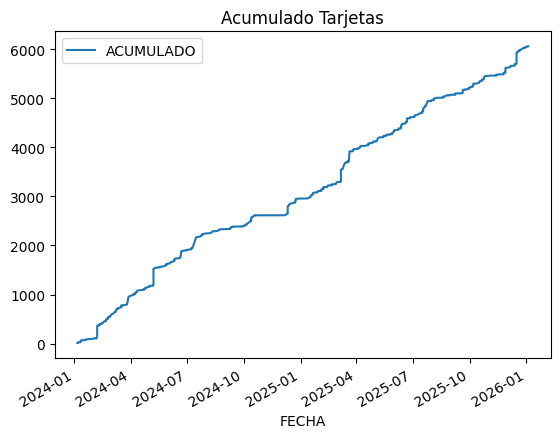

In [15]:
df_tarjetas.plot(x='FECHA', y='ACUMULADO', title='Acumulado Tarjetas')

## Unir Por Dia 

In [16]:
df_tarjeta_dias_unicos = df_tarjetas.groupby('FECHA').agg({
    "VALOR": "sum",
    "ACUMULADO":"last"
}).reset_index()

<Axes: title={'center': 'Acumulado Tarjetas'}, xlabel='FECHA'>

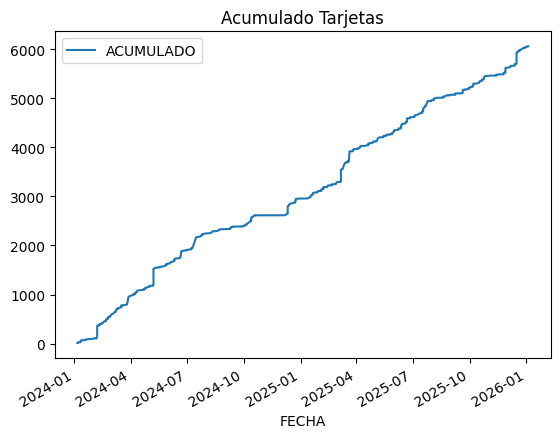

In [17]:
df_tarjetas.plot(x='FECHA', y='ACUMULADO', title='Acumulado Tarjetas')

# Notion

In [18]:
%load_ext autoreload
%autoreload 2
from contabilidad.notion import Lectura as LecturaNotion


from contabilidad.notion import integracionNotion

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Lectura

🔍 Obteniendo datos de la base de datos de usuarios...
🔍 Obteniendo datos de la tabla principal...


<Axes: title={'center': 'Acumulado Notion'}, xlabel='FECHA_REAL'>

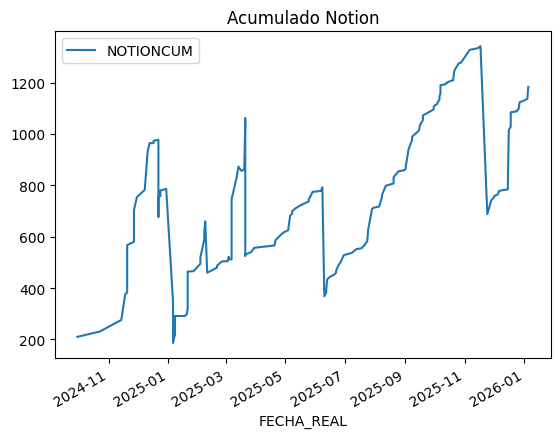

In [19]:
df_notion = LecturaNotion.leer_notion()
df_notion.plot(x='FECHA_REAL', y='NOTIONCUM', title='Acumulado Notion')

In [ ]:
# df_notion[(df_notion["PERSONA_NOTION"]=="Madre")& (df_notion["FECHA_CREACION"]>"2025-09-19")& (df_notion["Tipo"]=="Doy")].sort_values(by="FECHA_REAL")["NOTION"].sum()

np.float64(695.25)

In [20]:
notion_agrupado_dia=df_notion.groupby("FECHA_REAL").agg({
    "NOTION": "sum",
    "DESCRIPCION_NOTION": lambda x: '-|-'.join(x),
    "NOTIONCUM": "last"
}).rename_axis('FECHA').sort_index()
notion_agrupado_dia["DESCRIPCION_NOTION"] = notion_agrupado_dia["DESCRIPCION_NOTION"] + notion_agrupado_dia["NOTION"].apply(lambda x: f" (${x})")
notion_agrupado_dia.fillna({"DESCRIPCION_NOTION":""}, inplace=True)
notion_agrupado_dia

,NOTION,DESCRIPCION_NOTION,NOTIONCUM
FECHA,,,
2024-09-30,210.00,Pago dermatologo 30/9 ($210.0),210.00
2024-10-23,20.82,Medicamentos 23/10 ($20.82),230.82
2024-11-14,45.00,Banco Seguro ($45.0),275.82
2024-11-18,100.00,Inversion ($100.0),375.82
2024-11-20,191.50,Milanesa Uber-|-Doctor-|-Kfc-|-Pelo-|-Gotas-|-...,567.32
...,...,...,...
2025-12-26,6.00,Desayuno Taurus ($6.0),1096.06
2025-12-27,27.00,Stav ($27.0),1123.06
2025-12-30,4.60,Subscripcion Uber ($4.6),1127.66


<Axes: title={'center': 'Acumulado Notion por día'}, xlabel='FECHA'>

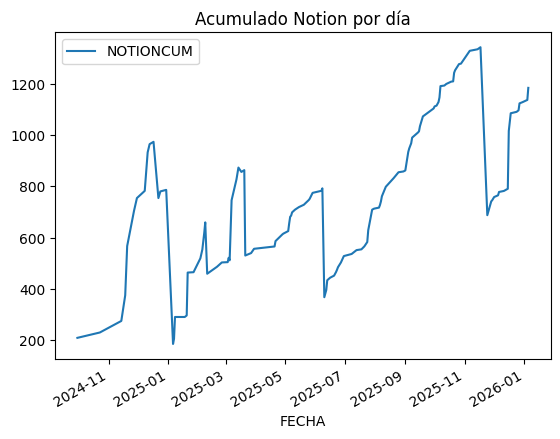

In [21]:
notion_agrupado_dia.plot(y='NOTIONCUM', title='Acumulado Notion por día')

# Unir

### Notion

In [48]:
df_unido_notion = df_cuenta_dias_unicos.merge(notion_agrupado_dia, left_on='FECHA', right_index=True, how='outer', suffixes=('', '_NOTION'))
df_unido_notion.sort_values(by='FECHA', inplace=True)
df_unido_notion.reset_index(drop=True, inplace=True)
df_unido_notion[df_unido_notion["NOTIONCUM"].notna()]

,FECHA,DEBITO,CREDITO,SALDO,MONTO,NOTION,DESCRIPCION_NOTION,NOTIONCUM
77,2024-09-30,216.95,0.0,69.32,-216.95,210.00,Pago dermatologo 30/9 ($210.0),210.00
86,2024-10-23,0.00,300.0,365.16,300.00,20.82,Medicamentos 23/10 ($20.82),230.82
91,2024-11-14,45.07,0.0,20667.20,-45.07,45.00,Banco Seguro ($45.0),275.82
93,2024-11-18,20313.00,0.0,309.09,-20313.00,100.00,Inversion ($100.0),375.82
95,2024-11-20,NaN,NaN,NaN,NaN,191.50,Milanesa Uber-|-Doctor-|-Kfc-|-Pelo-|-Gotas-|-...,567.32
...,...,...,...,...,...,...,...,...
346,2025-12-26,4906.04,0.0,33215.07,-4906.04,6.00,Desayuno Taurus ($6.0),1096.06
347,2025-12-27,NaN,NaN,NaN,NaN,27.00,Stav ($27.0),1123.06
349,2025-12-30,7.15,0.0,28269.26,-7.15,4.60,Subscripcion Uber ($4.6),1127.66
351,2026-01-04,NaN,NaN,NaN,NaN,8.80,Almuerzo Uber American Deli ($8.8),1136.46


### Tarjeta

In [49]:
df_tarjeta_unido =df_unido_notion.merge(df_tarjeta_dias_unicos, on='FECHA', how='outer', suffixes=('_TAR', '_TAR'))
df_tarjeta_unido = df_tarjeta_unido.sort_values('FECHA')
df_tarjeta_unido.rename(columns={"VALOR": "VALOR_TARJETA", "ACUMULADO": "ACUMULADO_TARJETA"}, inplace=True)
df_tarjeta_unido

,FECHA,DEBITO,CREDITO,SALDO,MONTO,NOTION,DESCRIPCION_NOTION,NOTIONCUM,VALOR_TARJETA,ACUMULADO_TARJETA
0,2024-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.79,23.79
1,2024-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.23,26.02
2,2024-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.39,48.41
3,2024-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.04,67.45
4,2024-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.39,70.84
...,...,...,...,...,...,...,...,...,...,...
469,2026-01-05,54.95,0.0,28208.41,-54.95,47.0,Concierto ($47.0),1183.46,NaN,NaN
470,2026-01-06,63.95,0.0,28144.46,-63.95,NaN,NaN,NaN,NaN,NaN
471,2026-01-07,2.25,0.0,28142.21,-2.25,NaN,NaN,NaN,NaN,NaN
472,2026-01-08,3.95,0.0,28138.26,-3.95,NaN,NaN,NaN,NaN,NaN


### Todo

In [50]:
df_unido = df_tarjeta_unido.copy()
columns_to_fill = ["SALDO","NOTIONCUM","ACUMULADO_TARJETA"]
columns_to_fill_with_zero = ["DEBITO", "CREDITO", "MONTO","NOTION","NOTIONCUM","VALOR_TARJETA"]
df_unido[columns_to_fill] = df_unido[columns_to_fill].ffill()
df_unido[columns_to_fill_with_zero] = df_unido[columns_to_fill_with_zero].fillna(0)
df_unido

,FECHA,DEBITO,CREDITO,SALDO,MONTO,NOTION,DESCRIPCION_NOTION,NOTIONCUM,VALOR_TARJETA,ACUMULADO_TARJETA
0,2024-01-06,0.00,0.0,NaN,0.00,0.0,NaN,0.00,23.79,23.79
1,2024-01-08,0.00,0.0,NaN,0.00,0.0,NaN,0.00,2.23,26.02
2,2024-01-11,0.00,0.0,NaN,0.00,0.0,NaN,0.00,22.39,48.41
3,2024-01-12,0.00,0.0,NaN,0.00,0.0,NaN,0.00,19.04,67.45
4,2024-01-17,0.00,0.0,NaN,0.00,0.0,NaN,0.00,3.39,70.84
...,...,...,...,...,...,...,...,...,...,...
469,2026-01-05,54.95,0.0,28208.41,-54.95,47.0,Concierto ($47.0),1183.46,0.00,6061.83
470,2026-01-06,63.95,0.0,28144.46,-63.95,0.0,NaN,1183.46,0.00,6061.83
471,2026-01-07,2.25,0.0,28142.21,-2.25,0.0,NaN,1183.46,0.00,6061.83
472,2026-01-08,3.95,0.0,28138.26,-3.95,0.0,NaN,1183.46,0.00,6061.83


# Marcar Variables

In [51]:
fecha_min_cuenta= df_cuenta["FECHA"].min()
fecha_min_tarjeta= df_tarjetas["FECHA"].min()
# fecha_min_notion = df_notion["FECHA"].min()
print(f"Fechas mínimas - Cuenta: {fecha_min_cuenta}, Tarjeta: {fecha_min_tarjeta}")

Fechas mínimas - Cuenta: 2024-03-11 00:00:00, Tarjeta: 2024-01-06 00:00:00


### PAGO MADRE

In [52]:
from contabilidad.Modelos import PAGO
from contabilidad.union import interpolar 

In [53]:
df_pagos_madre_marcado =df_unido.copy()
# df_pagos_madre_marcado["FECHA"] = df_pagos_madre_marcado["FECHA"].dt.normalize()
pagosMensualMa:list[PAGO]=[
    PAGO(monto=132,inicio='2024-10-02'),
    PAGO(monto=135,inicio='2024-11-05'),
    
    PAGO(monto=100,inicio="2025-01-06"),
    PAGO(monto=50,inicio ="2025-02-24"),
    PAGO(monto=100,inicio="2025-03-21"),
    PAGO(monto= 100,inicio="2025-04-23"),
    PAGO(monto=110,inicio="2025-05-22"),

    # PAGO(monto=300,inicio="2025-06-10"), # Pago gasolina

    PAGO(monto=100,inicio="2025-06-24"),
    PAGO(monto=50,inicio="2025-07-28"),
    PAGO(monto=110,inicio="2025-09-22"),
    PAGO(monto=185,inicio='2025-11-06'), #110 comida, 75 gasolina
    PAGO(monto=180, inicio="2025-11-24"),
    PAGO(monto=230, inicio="2025-12-22"), #110 comida, 75 gasolina, 40 parqueadero
    
]
pagosMensualMa = [pago for pago in pagosMensualMa if pd.to_datetime(pago.inicio) >= df_pagos_madre_marcado["FECHA"].min()]
for pago in pagosMensualMa:
    df_pagos_madre_marcado.loc[df_pagos_madre_marcado["FECHA"] == pago.inicio, "PAGOS_MENSUAL_MA"] = pago.monto
df_pagos_madre_marcado = interpolar.interpolar_a_cero(df_pagos_madre_marcado, "PAGOS_MENSUAL_MA")

#2024-04-26
#2024-09-25 572

# pagosMa:list[PAGO]=[
#     # PAGO(monto=401,inicio="2024-09-20"), # Creo que es mi propio pago
#     PAGO(monto=610,inicio="2024-09-22"), # Pago madre 610
#     PAGO(monto=249,inicio='2024-10-02'),
#     # PAGO(monto=300,inicio='2024-12-22'),
#     PAGO(monto=600,inicio ="2025-01-06"),
#     PAGO(monto=200,inicio="2025-02-10"),
#     PAGO(monto=535,inicio="2025-03-21"),

#     PAGO(monto=728,inicio="2025-06-10",descripcion="Gasolina300 y Pago428"),#gasolina 300
    
# ]
# pagosMa = [pago for pago in pagosMa if pd.to_datetime(pago.inicio) >= df_pagos_madre_marcado["FECHA"].min()]
# for pago in pagosMa:
#     df_pagos_madre_marcado.loc[df_pagos_madre_marcado["FECHA"] == pago.inicio, "PAGOS_MA"] = pago.monto


df_pagos_madre_marcado[df_pagos_madre_marcado["PAGOS_MENSUAL_MA"].notna()][["FECHA","DEBITO","CREDITO","PAGOS_MENSUAL_MA"]]

MODIFICANDO PAGOS_MENSUAL_MA - FECHAS: DatetimeIndex(['2024-10-02', '2024-11-05', '2025-01-06', '2025-02-24',
               '2025-03-21', '2025-04-23', '2025-05-22', '2025-06-24',
               '2025-07-28', '2025-09-22', '2025-11-06', '2025-11-24',
               '2025-12-22'],
              dtype='datetime64[ns]', name='FECHA', freq=None)
Rellenando desde 2024-10-02 00:00:00 hasta 2024-11-04 00:00:00 con valor final 135.0
Ramp: [  0.           4.09090909   8.18181818  12.27272727  16.36363636
  20.45454545  24.54545455  28.63636364  32.72727273  36.81818182
  40.90909091  45.          49.09090909  53.18181818  57.27272727
  61.36363636  65.45454545  69.54545455  73.63636364  77.72727273
  81.81818182  85.90909091  90.          94.09090909  98.18181818
 102.27272727 106.36363636 110.45454545 114.54545455 118.63636364
 122.72727273 126.81818182 130.90909091 135.        ]
Rellenando desde 2024-11-05 00:00:00 hasta 2025-01-05 00:00:00 con valor final 100.0
Ramp: [  0.           1.63934

,FECHA,DEBITO,CREDITO,PAGOS_MENSUAL_MA
154,2024-10-02,0.00,381.00,132.0
172,2024-11-05,0.00,132.00,135.0
198,2025-01-06,1.26,700.00,100.0
234,2025-02-24,18.01,50.00,50.0
255,2025-03-21,345.80,1235.00,100.0
282,2025-04-23,3.50,100.00,100.0
306,2025-05-22,4.75,110.00,110.0
333,2025-06-24,16.85,110.00,100.0
357,2025-07-28,7.50,50.00,50.0
394,2025-09-22,410.71,110.00,110.0


### INVERSIONES

In [54]:
%load_ext autoreload
%autoreload 2
import contabilidad.modulos.cuenta.ObtenerVariables as ObtenerVariablesCuenta

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
ObtenerVariablesCuenta.ver_inversiones(df_cuenta) 
inversiones:list[PAGO] = [  # ES CUANDO TENGO INVERSION EN MI CUENTA
    # PAGO(monto=3177, fin="2024-03-18"),
    # PAGO(monto=26000,fin="2024-03-28"),
    # PAGO(monto=10278, inicio="2024-05-29",fin="2024-06-04"),
    # PAGO(monto=10476,inicio='2024-09-04',fin='2024-09-23'),
    # PAGO(monto=9876,fin="2024-09-23"),
    # PAGO(monto=6675,inicio="2024-10-24",fin="2024-11-18"),
    # PAGO(monto=10003,inicio="2024-11-18",fin="2024-11-18"),
    # PAGO(monto = 13_536,inicio="2024-10-24",fin="2024-11-18"),
    # PAGO(monto=27_897,inicio="2025-01-24",fin="2025-02-21"),
    # PAGO(monto=10_530, inicio="2025-03-19", fin="2025-04-28"),
    # PAGO(monto=28_137, inicio="2025-03-24"),
    # PAGO(monto=600,inicio="2025-03-21"), #mi deposito
    # PAGO(monto=290,inicio="2025-02-03",fin="2025-02-05"),
    
    # PAGO(monto=26000,inicio="2024-03-28",fin="2025-01-24"), #1897

    # PAGO(monto=10100,fin="2024-05-29"),
    # PAGO(monto =10278, inicio="2024-06-04",fin="2024-09-04"),

    PAGO(monto=26000,fin='2024-03-28'),

    PAGO(monto=10272,inicio='2024-05-29',fin='2024-06-04'),
    
    # PAGO(monto=10468,inicio="2024-09-04"), # LA DIVIDO EN LAS DE ABAJO POR pago tarjeta  #!sobran 592?
    PAGO(monto=6648, inicio='2024-09-04', fin="2024-09-23"), #
    PAGO(monto=3228, inicio='2024-09-04', fin="2024-09-23"), #le pague la tarjeta a madre 

    PAGO(monto=6675, inicio="2024-10-24",fin="2024-11-18"),
    PAGO(monto=13536, inicio="2024-10-25",fin="2024-11-18"), #combinamos las 2 me faltan !100


    PAGO(monto=27897, inicio="2025-01-24",fin="2025-02-21"), #complete de mi dinero para los 28k
    PAGO(monto=-103,inicio="2025-02-21",fin="2025-03-24"), #el dinero que complete para los 28k

    PAGO(monto=290, inicio="2025-02-03", fin='2025-02-05'), #hermana me para guardar
    # PAGO(monto=10530, inicio="2025-03-19"), #creo que pague tarjeta a madre
    PAGO(monto=3213, inicio="2025-03-19",fin="2025-04-28"), #TARJETA
    PAGO(monto=7317, inicio="2025-03-19",fin='2025-04-28'), #RESTO INVERSION

    PAGO(monto=27000, inicio="2025-03-24",fin='2025-05-12'),
    PAGO(monto=1034, inicio="2025-03-24"), #El resto de la inversion

    PAGO(monto=27120, inicio="2025-06-12",fin="2025-08-12"), #mi deposito
    PAGO(monto=10390, inicio="2025-06-17",fin="2025-08-12"),
    PAGO(monto=-490,inicio="2025-08-12", fin="2025-09-12"), #el dinero que complete para los 38k

    #Estos dos unidos es la inversion de 38_113
    #1. Estos dos son uno solo de 10389
    PAGO(monto=7122, inicio="2025-09-12"), #restado de los 10389
    PAGO(monto=3267 ,inicio="2025-09-12", fin="2025-10-24"), # Pago tarjeta
    # 2
    PAGO(monto=27120 , inicio="2025-09-12"),
    #3
    PAGO(monto=604, inicio="2025-09-12"), #lo que sobra que puse de mi dinero solo para guardar y que no me robem de la cuenta




    PAGO(monto=7481.79, inicio="2025-09-25"),


    PAGO(monto=-600, fin="2025-03-21"), #Simular dinero que tenia en efectivo y despues deposite

]
df_inversiones_marcado = ObtenerVariablesCuenta.marcar_fijos(df_pagos_madre_marcado, inversiones, "INVERSION")
df_inversiones_marcado[df_inversiones_marcado["FECHA"] >= fecha_min_cuenta]



# MIA
# 1. 2024-03-28 - 2025-01-24 26000 - 27,897.57  
# puse 103
# 2. 2025-02-21 - 2025-03-24 28_000 - 28,137.04   Sin lo que puse al prinipio, la inversion vencida es en verdad es 28,034.04
# reste  1034
# 3. 2025-05-12 - 2025-06-12 27_000 - 27,120.77 : que en verdad seria 28154
# reste 543
#4  2025-08-12 - 2025-09-12 27,611-27,694 Es lo que me corresponde en la inversion unida de 38_000. Que en verdad seria  28237
# reste 1237
#5 2025-11-18 - 2025-12-19 27_000 27,067.43 Que en verdad seria  28304

#Inversiones
# 2025-01-24 - 2025-02-21 27897
# 2025-03-24 - 2025-05-12 28137
# 2025-05-12 - 2025-06-12  1034
# 2025-06-12-2025-08-12  28154
# 2025-08-12 - 2025-09-12  543
# 2025-09-12 - 2025-11-18   28237
inversiones_mias = [
    PAGO(monto=26000,fin="2024-03-28"), #
    PAGO(monto=27897, inicio="2025-01-24",fin="2025-02-21"), #
    PAGO(monto=-103,inicio="2025-02-21",fin="2025-03-24"), #
    PAGO(monto=28_034,inicio="2025-03-24",fin="2025-05-12"), #
    PAGO(monto=1034,inicio="2025-05-12",fin="2025-06-12"), #
    PAGO(monto=28154,inicio="2025-06-12",fin="2025-08-12"), #
    PAGO(monto=543,inicio="2025-08-12",fin="2025-09-12"), #
    PAGO(monto=28237,inicio="2025-09-12", fin="2025-11-18"), #
    PAGO(monto=1237,inicio="2025-11-18",fin="2025-12-19"), #
    PAGO(monto=28304,inicio="2025-12-19"), #
]



# Uni
# 1 . Nose -  2024-05-29 10100-10,272.21
# 2. 2024-06-04 - 2024-09-04 10278-10,486.82
# Se paga tarjeta 3228 queda 7258
#Pago madre 610
# 3. 2024-09-23 - 2024-10-24 6648-6,675.48
# Se aumenta 3_635 de Madre para mejorar intereses
# 4. 2024-11-18 - 2025-03-19  10_310-10,530.74
# Se paga tarjeta 3213 queda 7317
# 5 2025-04-28 - 2025-09-25 7317-7,481.33
# Se paga uni 3267 queda 4,214
# 6 2025-11-18 - Nose 4214-

#Inversiones
#2024-05-29 - 2024-06-04 10_272
#2024-09-04 - 2024-09-23 7258
#2024-09-04 - 2024-09-23 3228
#2024-10-24 - 2024-11-18 6,675.48
#2025-03-19 - 2025-04-28 7317
#2025-03-19 - 2025-04-28 3213
#2025-09-25 - 2025-10-24 3267
#2025-09-25 - 2025-11-18 4214

inversiones_uni = [
    PAGO(monto=10100,fin="2024-05-29"),
    PAGO(monto =10272, inicio="2024-05-29",fin="2024-06-04"),
    PAGO(monto=7258, inicio='2024-09-04', fin="2024-09-23"), #
    PAGO(monto=3228, inicio='2024-09-04', fin="2024-09-23"), #le pague la tarjeta a madre 
    PAGO(monto=6675, inicio="2024-10-24",fin="2024-11-18"),
    PAGO(monto=7317, inicio="2025-03-19",fin="2025-04-28"), #
    PAGO(monto=3213, inicio="2025-03-19",fin="2025-04-28"), #
    PAGO(monto=3267, inicio="2025-09-25", fin="2025-10-24"), #
    PAGO(monto=4214, inicio="2025-09-25", fin="2025-11-18"), #
]



# Madre
# 1. Nose - 2024-10-25 12,854.21-13,536.83
# Se Quita 3_635 para Uni para mejorar inversion    Se queda con 9901
# Puse 102 para completar para la inversion 
# 2. 2024-11-18 - 2025-06-17 10_003-10,389.95
# 3. 2025-08-12-2025-09-12 10,389-10,419  # es lo que corresponde en la inversion unida
# 4. 2025-11-18 - 2025-12-22 10_419-10,447.54
# 2025-12-26 Transferi 4900 a renault para el carro
# 2025-12-29 Transferi 4900 a hermana para el carro

#Inversiones
# 2024-10-25 - 2024-11-18 13,536.83
# 2025-06-17 - 2025-08-12 10_389.95
# 2025-09-12 - 2025-11-18 10_419

# 2025-12-22 - 2025-12-26 4900
# 2025-12-22 - 20250-12-29 4900
# 2025-12-22 - Nose 647

inversiones_madre = [
    PAGO(monto=13536, inicio="2024-10-25",fin="2024-11-18"), #
    PAGO(monto=10389, inicio="2025-06-17",fin="2025-08-12"), #
    PAGO(monto=10419, inicio="2025-09-12", fin="2025-11-18"), #
    PAGO(monto=4900, inicio="2025-12-22", fin="2025-12-26"), #
    PAGO(monto=4900, inicio="2025-12-22", fin="2025-12-29"), #
    PAGO(monto=647, inicio="2025-12-22"), #
]
inversiones_para_corregir= [
    PAGO(monto=-600, fin="2025-03-21"), ##Simular dinero que tenia en efectivo y despues deposite
    PAGO(monto=290, inicio="2025-02-03", fin='2025-02-05'), #hermana me para guardar
]
inversiones = inversiones_mias + inversiones_uni + inversiones_madre + inversiones_para_corregir
df_inversiones_marcado = ObtenerVariablesCuenta.marcar_fijos(df_pagos_madre_marcado, inversiones, "INVERSION")
df_inversiones_marcado[df_inversiones_marcado["FECHA"] >= fecha_min_cuenta]



------INVERSIONES
                 FECHA              DESCRIPCION     MONTO
19 2024-03-28 00:00:00  CERTIFICADO DE DEPOSITO -26000.00
0  2024-05-29 00:00:00   CANCELACION PLAZO FIJO  10100.00
20 2024-06-04 00:00:00  CERTIFICADO DE DEPOSITO -10278.00
1  2024-09-04 00:00:00   CANCELACION PLAZO FIJO  10278.00
21 2024-09-23 00:00:00  CERTIFICADO DE DEPOSITO  -6648.00
2  2024-10-24 00:00:00   CANCELACION PLAZO FIJO   6648.00
3  2024-10-24 00:00:00   CANCELACION PLAZO FIJO     27.48
4  2024-10-25 00:00:00   CANCELACION PLAZO FIJO  12854.21
5  2024-10-25 00:00:00   CANCELACION PLAZO FIJO    682.63
22 2024-11-18 00:00:00  CERTIFICADO DE DEPOSITO -10310.00
23 2024-11-18 00:00:00  CERTIFICADO DE DEPOSITO -10003.00
7  2025-01-24 00:00:00   CANCELACION PLAZO FIJO   1897.57
6  2025-01-24 00:00:00   CANCELACION PLAZO FIJO  26000.00
24 2025-02-21 00:00:00  CERTIFICADO DE DEPOSITO -28000.00
9  2025-03-19 00:00:00   CANCELACION PLAZO FIJO    225.25
8  2025-03-19 00:00:00   CANCELACION PLAZO FIJO  10310

,FECHA,DEBITO,CREDITO,SALDO,MONTO,NOTION,DESCRIPCION_NOTION,NOTIONCUM,VALOR_TARJETA,ACUMULADO_TARJETA,PAGOS_MENSUAL_MA,PAGOS_MENSUAL_MA INTER,INVERSION
29,2024-03-11,29.50,0.0,31823.39,-29.50,0.0,NaN,0.00,22.39,721.47,NaN,31.777778,35500.0
30,2024-03-12,10.23,0.0,31813.16,-10.23,0.0,NaN,0.00,0.00,721.47,NaN,32.266667,35500.0
31,2024-03-13,22.25,0.0,31790.91,-22.25,0.0,NaN,0.00,4.99,726.46,NaN,32.755556,35500.0
32,2024-03-14,4.50,0.0,31786.14,-4.50,0.0,NaN,0.00,0.00,726.46,NaN,33.244444,35500.0
33,2024-03-15,5.38,0.0,31780.76,-5.38,0.0,NaN,0.00,11.60,738.06,NaN,33.733333,35500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,2026-01-05,54.95,0.0,28208.41,-54.95,47.0,Concierto ($47.0),1183.46,0.00,6061.83,NaN,0.000000,28951.0
470,2026-01-06,63.95,0.0,28144.46,-63.95,0.0,NaN,1183.46,0.00,6061.83,NaN,0.000000,28951.0
471,2026-01-07,2.25,0.0,28142.21,-2.25,0.0,NaN,1183.46,0.00,6061.83,NaN,0.000000,28951.0
472,2026-01-08,3.95,0.0,28138.26,-3.95,0.0,NaN,1183.46,0.00,6061.83,NaN,0.000000,28951.0


In [56]:
inversiones.sort(key=lambda pago: pd.to_datetime(pago.inicio) if pago.inicio else pd.to_datetime(pago.fin))
inversiones

[PAGO(monto=26000, inicio=None, fin='2024-03-28', descripcion=None),
 PAGO(monto=10100, inicio=None, fin='2024-05-29', descripcion=None),
 PAGO(monto=10272, inicio='2024-05-29', fin='2024-06-04', descripcion=None),
 PAGO(monto=7258, inicio='2024-09-04', fin='2024-09-23', descripcion=None),
 PAGO(monto=3228, inicio='2024-09-04', fin='2024-09-23', descripcion=None),
 PAGO(monto=6675, inicio='2024-10-24', fin='2024-11-18', descripcion=None),
 PAGO(monto=13536, inicio='2024-10-25', fin='2024-11-18', descripcion=None),
 PAGO(monto=27897, inicio='2025-01-24', fin='2025-02-21', descripcion=None),
 PAGO(monto=290, inicio='2025-02-03', fin='2025-02-05', descripcion=None),
 PAGO(monto=-103, inicio='2025-02-21', fin='2025-03-24', descripcion=None),
 PAGO(monto=7317, inicio='2025-03-19', fin='2025-04-28', descripcion=None),
 PAGO(monto=3213, inicio='2025-03-19', fin='2025-04-28', descripcion=None),
 PAGO(monto=-600, inicio=None, fin='2025-03-21', descripcion=None),
 PAGO(monto=28034, inicio='2025-

In [57]:
# import plotly.express as px
import plotly.graph_objects as go


fecha_inicio_grafico = df_inversiones_marcado['FECHA'].min()
fecha_fin_grafico = df_inversiones_marcado['FECHA'].max()

fig = go.Figure()
fig.add_trace(
    go.Scatter( # Nota: Usar go.Scatter(mode='lines') es más estándar que go.Line
        x=df_inversiones_marcado['FECHA'],
        y=df_inversiones_marcado["INVERSION"],
        mode='lines',
        name='INVERSION'
    )
)
fig.add_trace(
    go.Scatter(
        x=df_inversiones_marcado['FECHA'],
        y=df_inversiones_marcado["SALDO"],
        mode='lines+markers',
        name='SALDO'
    )
)

# --- 5. BUCLE MEJORADO PARA AÑADIR MARCAS |----| ---
for index, pago in enumerate(inversiones):
    monto = pago.monto
    inicio = pd.to_datetime(pago.inicio)
    fin = pd.to_datetime(pago.fin)

    if pd.isna(inicio):
        inicio = fecha_inicio_grafico
    if pd.isna(fin):
        fin = fecha_fin_grafico

    # Para el hover unificado, podemos construir el texto aquí
    hover_text = (
        # f'<b>{pago.nombre}</b><br>'
        f'Monto: ${monto:,.0f}<br>'
        f'Inicio: {inicio.strftime("%Y-%m-%d")}<br>'
        f'Fin: {fin.strftime("%Y-%m-%d")}<extra></extra>' # <extra></extra> oculta el nombre del trace
    )

    fig.add_trace(
        go.Scatter(
            x=[inicio, fin],
            y=[monto, monto],
            mode='lines+markers',
            line=dict(color='yellow', width=3, dash='solid'),
            marker=dict(
                size=10,
                color='yellow',
                symbol='line-ns'
            ),
            name=f"Inv {index+1}", # Usamos el nombre del pago para la leyenda
            legendgroup='Inversiones_P',
            showlegend=True if index == 0 else False, # Mostrar la leyenda solo una vez para el grupo
            hoveron='points+fills',
            hoverinfo='text', # ¡Importante! Usamos 'text' y definimos hovertemplate
            hovertemplate=hover_text # Aquí usamos el texto personalizado que creamos
        )
    )
# --- 6. MOSTRAR GRÁFICA ---
fig.update_layout(
    title='Gráfico de Inversiones y Saldo con Fechas Flexibles',
    xaxis_title='Fecha',
    yaxis_title='Monto',
    hovermode='x unified'
)

fig.show()

### TARJETA

In [58]:
pagos_tarjeta = ObtenerVariablesCuenta.obtener_pagos_tarjetas(df_cuenta)
pagos_filtrados_dia = [pago for pago in pagos_tarjeta if pd.to_datetime(pago.inicio) >= df_cuenta["FECHA"].min()]
df_tarjeta_marcado = ObtenerVariablesCuenta.marcar_fijos(df_inversiones_marcado, pagos_filtrados_dia, "PAGO_TARJETA", incluir_ultimo=True)
df_tarjeta_marcado["PAGO_TARJETA"]  = df_tarjeta_marcado["PAGO_TARJETA"].fillna(0)
df_tarjeta_marcado["TARJETA"] = df_tarjeta_marcado["ACUMULADO_TARJETA"] - df_tarjeta_marcado["PAGO_TARJETA"]
df_tarjeta_marcado["TARJETA"] = df_tarjeta_marcado["TARJETA"].fillna(0)

Pagos encontrados de tarjeta:
                  FECHA     SALDO  \
17  2024-03-18 00:00:00  28113.78   
19  2024-03-18 00:00:00  27826.40   
73  2024-06-20 00:00:00   1993.48   
100 2024-07-22 00:00:00   1727.28   
113 2024-08-06 00:00:00   1440.21   
122 2024-08-21 00:00:00   1259.80   
146 2024-09-20 00:00:00  10205.27   
189 2024-11-15 00:00:00  20622.09   
192 2024-11-19 00:00:00     22.11   
229 2025-01-21 00:00:00    661.36   
232 2025-01-22 00:00:00    242.84   
268 2025-02-21 00:00:00  28120.00   
304 2025-03-21 00:00:00  10525.09   
311 2025-03-21 00:00:00  11434.29   
362 2025-04-21 00:00:00  39249.14   
385 2025-05-07 00:00:00  27947.79   
472 2025-06-23 00:00:00  38995.30   
473 2025-06-23 00:00:00  38779.20   
516 2025-07-21 00:00:00  38544.44   
517 2025-07-21 00:00:00  38524.44   
554 2025-08-21 00:00:00    288.22   
585 2025-09-22 00:00:00  37765.63   
611 2025-10-21 00:00:00  45318.49   
628 2025-11-05 13:34:00  41799.55   
658 2025-11-21 09:33:00     96.96   
679 2025

In [59]:
%load_ext autoreload
%autoreload 2
from contabilidad.union import cortar_tarjeta as cortar_tarjeta

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
df_cuadrado=cortar_tarjeta.cortar_dia(df_unido=df_tarjeta_marcado, datos_tarjetas=datos_tarjetas, primer_dia=pd.to_datetime("2025-01-01"), pagos_tarjeta=pagos_tarjeta, df_tarjetas=df_tarjetas)

Deuda anterior al primer día: -44.69
Pagos de tarjeta entre 2024-12-06 00:00:00 y 2025-01-01 00:00:00:
[]
PAGO DE ESTADO DE TARJETA VIGENTE anterior a la fecha dada: Entre 2024-12-06 00:00:00 y 2025-01-01 00:00:00: 0
Deuda calculada: -44.69
Consumos de tarjeta anteriores a la fecha: Entre 2024-12-07 00:00:00 y 2025-01-01 00:00:00:
          FECHA                DESCRIPCION   VALOR OPERACION  ACUMULADO  \
236 2024-12-07  PYCCA EL RECREOA        Q    4.97   CONSUMO    2621.31   
237 2024-12-08  MB-MAYFLOWER BUFFALOS   Q    6.99   CONSUMO    2628.30   
238 2024-12-10  ROCK YOUR DOGS          E   20.50   CONSUMO    2648.80   
239 2024-12-11  RET IVA SERV DIGITAL 100%    0.45       N/D    2649.25   
240 2024-12-11  GOOGLE *Palette Home S  8    2.99   CONSUMO    2652.24   
241 2024-12-11  ESTACIONAMIENTOS URBAN  Q    2.00   CONSUMO    2654.24   
242 2024-12-11  DERMAAID  ECUECU        Q  145.00   CONSUMO    2799.24   
245 2024-12-13  MEDICITY LA PAMPA       Q   14.32   CONSUMO    2813.56   


In [61]:
from contabilidad.analisis import tarjeta as AnalisisTarjeta

In [62]:
AnalisisTarjeta.visualizar_tarjeta_pago(df_cuadrado,datos_tarjetas,pagos_tarjeta)

## TOTAL

In [63]:
df_total  = df_cuadrado.copy()
df_total["TOTAL"] = df_total["SALDO"] - df_total["ACUMULADO_TARJETA"] + df_total["PAGO_TARJETA"]  - df_total["INVERSION"] + df_total["PAGOS_MENSUAL_MA INTER"] + df_total["NOTIONCUM"].fillna(0)

In [190]:
# df_total[["SALDO","INVERSION","FECHA"]].plot(x='FECHA', title='Saldo e Inversiones')
# df_total["SALDO_MINUS_INVERSION"] = df_total["SALDO"] - df_total["INVERSION"]
# df_total[["SALDO_MINUS_INVERSION","FECHA"]].plot(x='FECHA', title='Saldo menos Inversiones')
# df_total[["TOTAL","FECHA","SALDO","ACUMULADO_TARJETA"]].plot(x='FECHA', title='Total Final')
# df_total.query("FECHA >= '2025-11-10'")[["FECHA","SALDO","INVERSION","SALDO_MINUS_INVERSION","ACUMULADO_TARJETA","PAGO_TARJETA","NOTIONCUM","TOTAL"]]

# Descripciones


## Extraer Descripciones

In [64]:
%load_ext autoreload
%autoreload 2
from contabilidad.descripciones.leer import leer_descripciones

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
df_descripciones=leer_descripciones()
df_desc = df_total.merge(df_descripciones[["FECHA","DESCRIPCION","MADRE"]], on='FECHA', how='left', suffixes=('', '_desc2'))
df_desc[df_desc["DESCRIPCION"].notna() & df_desc["DESCRIPCION"].str.strip().astype(bool)][["FECHA","DESCRIPCION"]].tail()
# df_descripciones

Leyendo descripciones de: ../data/completos/validacion/2026-01-08/descripciones.xlsx


,FECHA,DESCRIPCION
269,2025-12-31,"Almuerzo 4, Desayuno 2"
270,2026-01-01,Regalo Noah Navidad BrawlStars 9
271,2026-01-04,"Juego 6, Almuerzo 9"
272,2026-01-05,"Almuerzos 8, Concierto 47"
273,2026-01-06,"Parqueadero 60, Almuerzo 4"


# Visualizar

In [66]:
from contabilidad.analisis import diferencias 

In [67]:
df_dif_desc = diferencias.get_diferencias(df_desc)
df_dif_desc

,FECHA,VALOR_TARJETA,ACUMULADO_TARJETA,DEBITO,CREDITO,SALDO,MONTO,NOTION,DESCRIPCION_NOTION,NOTIONCUM,...,diff_total_dias,diff_tarjeta,diff_tarjeta_dias,saldo_sin_inversion,diff_saldo_sin_inversion,diff_pago_tarjeta,diff_tarjeta_real,diff_notion,diff_TOTAL,diff_TOTAL_dias
0,2024-12-31,295.27,295.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-06,0.00,295.27,1.26,700.0,759.79,698.74,-600.0,Pagado madre-|-Pagado completo ($-600.0),186.23,...,NaN,0.0,0.0,1359.79,NaN,0.0,0.0,NaN,NaN,NaN
2,2025-01-07,0.00,295.27,20.00,0.0,739.79,-20.00,20.0,Gasolina ($20.0),206.23,...,1.041667,0.0,0.0,1339.79,-20.00,0.0,0.0,20.0,1.041667,1.041667
3,2025-01-08,0.00,295.27,0.00,0.0,739.79,0.00,85.0,Pelo-|-Cambio centavos-|-Gotas ($85.0),291.23,...,86.041667,0.0,0.0,1339.79,0.00,0.0,0.0,85.0,86.041667,86.041667
4,2025-01-09,0.00,295.27,6.00,0.0,733.79,-6.00,0.0,NaN,291.23,...,-4.958333,0.0,0.0,1333.79,-6.00,0.0,0.0,0.0,-4.958333,-4.958333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,2026-01-05,0.00,3400.80,54.95,0.0,28208.41,-54.95,47.0,Concierto ($47.0),1183.46,...,-7.850000,0.0,0.0,-742.59,-54.85,0.0,0.0,47.0,-7.850000,-7.850000
273,2026-01-06,0.00,3400.80,63.95,0.0,28144.46,-63.95,0.0,NaN,1183.46,...,-63.950000,0.0,0.0,-806.54,-63.95,0.0,0.0,0.0,-63.950000,-63.950000
274,2026-01-07,0.00,3400.80,2.25,0.0,28142.21,-2.25,0.0,NaN,1183.46,...,-2.250000,0.0,0.0,-808.79,-2.25,0.0,0.0,0.0,-2.250000,-2.250000
275,2026-01-08,0.00,3400.80,3.95,0.0,28138.26,-3.95,0.0,NaN,1183.46,...,-3.950000,0.0,0.0,-812.74,-3.95,0.0,0.0,0.0,-3.950000,-3.950000


## Graficos

### Basico

<Axes: title={'center': 'TOTAL Suavizado'}, xlabel='FECHA', ylabel='TOTAL'>

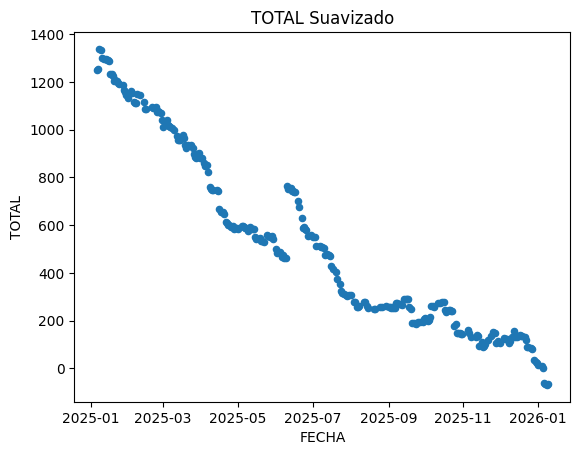

In [68]:
df_dif_desc.plot.scatter(x="FECHA", y="TOTAL", title="TOTAL Suavizado")

### Completo

In [69]:
from contabilidad.analisis.completo import Trace,Graficos,obtener_traces

In [70]:
df_grafico = df_dif_desc[(df_dif_desc["FECHA"] >= '2025-01-01')].copy()

grafico = Graficos(df_grafico)
grafico.agregar_traces_defecto()

highlighted_days = [
    '2024-06-22',
    '2024-09-30',
    '2025-03-22',
    "2025-01-31",
    "2025-07-18",
    "2025-09-27",
]
grafico.add_highlighteds_day(highlighted_days)
# grafico.show_pendiente(inicio, fin)
# grafico.show_pendiente('2025-01-08', '2025-06-10')
grafico.show_pendiente('2025-01-08', '2025-12-19')
grafico.show_pendiente('2025-06-10', '2025-12-19')
grafico.show_pendiente('2025-01-08', '2025-06-10')
grafico.show_pendiente('2025-09-25', '2025-12-19')
grafico.show_pendiente('2025-01-31', '2025-03-20')
grafico.show_pendiente('2025-07-18', '2025-09-27')

# grafico.show_pendiente('2024-05-01', '2024-08-22')
# grafico.show_pendiente('2024-05-01', '2025-01-08')
# grafico.add_last_day_card()

grafico.plot()

Pendiente entre 2025-01-08 y 2025-12-19: -3.48 por día
Total 136.22296296296008 - 1337.8333333333333 = -1201.6103703703732
Pendiente entre 2025-06-10 y 2025-12-19: -3.28 por día
Total 136.22296296296008 - 765.3149999999996 = -629.0920370370395
Pendiente entre 2025-01-08 y 2025-06-10: -3.74 por día
Total 765.3149999999996 - 1337.8333333333333 = -572.5183333333337
Pendiente entre 2025-09-25 y 2025-12-19: -0.66 por día
Total 136.22296296296008 - 192.49363636363694 = -56.270673400676856
Pendiente entre 2025-01-31 y 2025-03-20: -4.40 por día
Total 922.1900000000006 - 1133.441666666667 = -211.25166666666644
Pendiente entre 2025-07-18 y 2025-09-27: -3.10 por día
Total 196.31272727272403 - 416.21363636363753 = -219.9009090909135
[<contabilidad.analisis.completo.Trace object at 0x000001FBCF8A1E80>, <contabilidad.analisis.completo.Trace object at 0x000001FBCF978E10>, <contabilidad.analisis.completo.Trace object at 0x000001FBCF978F50>, <contabilidad.analisis.completo.Trace object at 0x000001FBCF9

In [198]:
# df_dif_desc[df_dif_desc["DESCRIPCION"].str.contains("olina")][["FECHA","MONTO","TARJETA","DESCRIPCION"]]

### DIFERENCIAS

In [71]:
from contabilidad.analisis.diferencias import graficar_diferencias

In [72]:
graficar_diferencias(df_dif_desc)

In [73]:
%load_ext autoreload
%autoreload 2
import contabilidad.analisis.datosCrudos as AnalisisDatosCrudos
import contabilidad.analisis.datosCrudos as VisualizadorAnalisis


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:


VisualizadorAnalisis.visualizar_todo(df_cuenta=df_cuenta, df_tarjetas=df_tarjetas, df_completo=df_dif_desc)

(OK) Fuente 'movimientos_cuenta' configurada.
(OK) Fuente 'movimientos_tarjeta' configurada.
(OK) Fuente 'movimientos_completo' configurada.
(OK) Fuente 'movimientos_completo_diff' configurada.
(INFO) Fuente combinada 'Todas' generada exitosamente.


In [75]:
df_cuenta[df_cuenta["DESCRIPCION"].str.contains("JESSENIA")][["FECHA","MONTO","DESCRIPCION"]]

,FECHA,MONTO,DESCRIPCION
591,2025-10-01 00:00:00,-7.90,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
646,2025-11-13 12:29:00,-3.95,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
657,2025-11-19 12:43:00,-3.95,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
666,2025-11-27 13:15:00,-3.50,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
677,2025-12-01 12:54:00,-3.50,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
680,2025-12-04 13:21:00,-3.95,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
688,2025-12-08 14:48:00,-3.50,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
698,2025-12-17 13:11:00,-3.95,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
721,2025-12-24 14:10:00,-6.50,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...
733,2026-01-05 13:46:00,-3.95,TRANSF. DEUNA A JESSENIA PATRICIA DELGADO ZAMB...


# Guardar

## Cuentas

In [76]:
from contabilidad.descripciones import leer as LeerDescripciones

In [77]:
LeerDescripciones.imprimir_excel(df_completo=df_dif_desc)

Guardando descripciones en: ../data/completos/validacion/2026-01-08/descripciones.xlsx


In [60]:
%load_ext autoreload
%autoreload 2 
from contabilidad.guardar import cuentas as guardar_cuentas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
guardar_cuentas.guardar_archivo_banca_completo(df=df_cuenta, nombre="HaciendoDiciembre", guardar_definitivo=False)

NameError: name 'guardar_cuentas' is not defined

## Tarjetas

In [52]:
%load_ext autoreload
%autoreload 2
from contabilidad.guardar import tarjetas as guardar_tarjetas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
guardar_tarjetas.guardar_archivo_tarjeta(df=df_tarjetas, nombre="prueba", guardar_definitivo=False)

Guardado en: ../data/historico/tarjeta/completos/prueba_2025-09-20.xlsx


## Unidos

In [78]:
%load_ext autoreload
%autoreload 2
from contabilidad.guardar import atipicos  as guardar_atipicos
from contabilidad.guardar import completos  as guardar_completo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'PATH_UNIDO' from 'contabilidad.config' (c:\Users\andre\Programacion\Cuentas\contabilidad\config.py)

In [61]:
guardar_atipicos.guardar_archivo(df=df_dif_desc, nombre="diferencias",guardar_definitivo=False)

Guardando archivo...
Guardado en: ../data/historico/atipicos/diferencias_2025-09-20.xlsx


In [62]:
guardar_completo.guardar_archivo_completo(df=df_dif_desc, nombre="completo",guardar_definitivo=False)

Guardado en: ../data/historico/completos/completo_2025-09-20.xlsx


In [84]:
%load_ext autoreload
%autoreload 2
from contabilidad.guardar import guardar
from contabilidad.guardar import verificacion_cambios

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
%reload_ext autoreload

In [82]:
%load_ext autoreload
%autoreload 2
from contabilidad.modulos.cuenta.lectura.FileProcessingConfig import FileProcessingConfig 
from contabilidad.modulos.cuenta.lectura import cuenta as LecturaCuenta
# from contabilidad.config import PATH_ATIPICOS_ACTUAL,PATH_DECRIPCIONES_ACTUAL,PATH_CUENTAS_ACTUAL,PATH_COMPLETOS_VALIDACION,PATH_COMPLETOS,PATH_CUENTAS_UNIDO_NOMBRE,NOMBRE_BANCA
from contabilidad.Modelos import DataCambiosGuardadoCuenta,DataCambiosGuardado,EnhancedJSONEncoder
import json

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
df_cuenta

,FECHA,SALDO,DESCRIPCION,DEBITO,CREDITO,MONTO
0,2024-03-11 00:00:00,31850.39,TRANSFERENCIA INTERBANCARIA ENVIADA,2.50,0.0,-2.50
1,2024-03-11 00:00:00,31848.39,TRANSFERENCIA INTERBANCARIA ENVIADA,2.00,0.0,-2.00
2,2024-03-11 00:00:00,31839.39,TRANSFERENCIA INTERNET,9.00,0.0,-9.00
3,2024-03-11 00:00:00,31823.39,TRANSFERENCIA INTERBANCARIA ENVIADA,16.00,0.0,-16.00
4,2024-03-12 00:00:00,31819.40,TRANSFERENCIA INTERBANCARIA ENVIADA,3.99,0.0,-3.99
...,...,...,...,...,...,...
559,2025-09-04 09:17:00,198.66,TRANSF. DIRECTA A VERKADE MONTIEL DOMINIQUE L...,72.51,0.0,-72.51
560,2025-09-05 13:11:00,184.92,TRANSF. DEUNA A DISTRIBUIDORA FARMACEUTICA ECU...,13.74,0.0,-13.74
561,2025-09-05 13:19:00,180.92,TRANSF. DIRECTA A SANCHEZ JARA DAISY ELIZABETH,4.00,0.0,-4.00
562,2025-09-09 12:47:00,177.67,TRANSFERENCIA INTERBANCARIA A GREGORY ALESSAND...,3.25,0.0,-3.25


In [85]:
verificacion_cambios.verificar_cambios(df_completo=df_dif_desc,df_cuentas=df_cuenta,cuenta_nueva_config=config_new_file)

AttributeError: module 'contabilidad.guardar.verificacion_cambios' has no attribute 'verificar_cambios'

In [86]:
verificacion_cambios.verificar_nuevas_cuentas(df_cuenta)

TypeError: verificar_nuevas_cuentas() missing 1 required positional argument: 'df_cuentas_comprobacion'

In [87]:
guardar.guardar_prueba_nuevos_datos(df_completo=df_dif_desc,df_cuentas=df_cuenta,nueva_cuenta_config=config_new_file)

Encabezados encontrados en la fila 5 (Excel)
['MONTO']
Guardando en: ../data/completos/validacion/2026-01-14
Datos Completos Guardado en: ../data/completos/validacion/2026-01-14/completo.xlsx
Cuentas Guardado en: ../data/completos/validacion/2026-01-14/banca.xlsx
 Datos guardados exitosamente en '../data/completos/validacion/2026-01-14/metadata.json'
Guardado descripciones en: ../data/completos/validacion/2026-01-14/descripciones.xlsx


In [97]:
guardar.guardar_nuevos_datos_finales(df_completo=df_dif_desc,df_cuentas=df_cuenta,nueva_cuenta_config=config_new_file)

Encabezados encontrados en la fila 5 (Excel)
['MONTO']
Guardando en: ../data/completos/2025-11-13
Datos Completos Guardado en: ../data/completos/2025-11-13/completo.xlsx
Cuentas Guardado en: ../data/completos/2025-11-13/banca.xlsx
 Datos guardados exitosamente en '../data/completos/2025-11-13/metadata.json'
Archivo JSON actualizado correctamente en '../data/config.json'


In [93]:
config_new_file